In [2]:
import torch

# If there's a GPU available...
if torch.cuda.is_available():

    # Tell PyTorch to use the GPU.
    device = torch.device("cuda")

    print('There are %d GPU(s) available.' % torch.cuda.device_count())

    print('We will use the GPU:', torch.cuda.get_device_name(0))
    !nvidia-smi

# If not...
else:
    print('No GPU available, using the CPU instead.')
    device = torch.device("cpu")

There are 1 GPU(s) available.
We will use the GPU: NVIDIA GeForce RTX 3060
Tue Feb 10 15:48:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060        On  |   00000000:01:00.0  On |                  N/A |
| 30%   34C    P8              7W /  170W |     540MiB /  12288MiB |     10%      Default |
|                                         |                      

In [3]:
!pip install -U transformers datasets accelerate
!pip install farasapy
!pip install pyarabic
!git clone https://github.com/aub-mind/arabert
!pip install emoji
!pip install sentencepiece

fatal: destination path 'arabert' already exists and is not an empty directory.


In [4]:
import pandas as pd
import numpy as np
from typing import List
from tqdm import tqdm_notebook as tqdm
from sklearn.model_selection import train_test_split

In [5]:
class CustomDataset:
    def __init__(
        self,
        name: str,
        train: List[pd.DataFrame],
        test: List[pd.DataFrame],
        # val: List[pd.DataFrame],
        label_list: List[str],
    ):
        """Class to hold and structure datasets.

        Args:

        name (str): holds the name of the dataset so we can select it later
        train (List[pd.DataFrame]): holds training pandas dataframe with 2 columns ["text","label"]
        test (List[pd.DataFrame]): holds testing pandas dataframe with 2 columns ["text","label"]
        label_list (List[str]): holds the list  of labels
        """
        self.name = name
        self.train = train
        self.test = test
        # self.val = val
        self.label_list = label_list

In [6]:
# This will hold all the downloaded and structred datasets
all_datasets= []
DATA_COLUMN = "text"
LABEL_COLUMN = "label"

In [7]:
def data_transformation(df) :
    data = []
    for _, row in df.iterrows():
        for column in df.columns:
            data.append({"Text": row[column], "Dialect": column})

    # Convert the list to a DataFrame
    return pd.DataFrame(data)

In [8]:
LEB = pd.read_csv("Lebanees.txt",encoding='utf-8', header = None)
LEB.columns = ["text"]
LEB["label"] = "Leb"
PAL = pd.read_csv("Palestinian.txt",encoding='utf-8',header= None)
PAL.columns = ["text"]
PAL["label"] = "Pal"
SYR = pd.read_csv("syrian.txt",encoding='utf-8',header= None)
SYR.columns = ["text"]
SYR["label"] = "Syr"
JRD = pd.read_csv("jordinian.txt",encoding='utf-8',header= None)
JRD.columns = ["text"]
JRD["label"] = "Jrd"

In [9]:
data  = [LEB, PAL, SYR, JRD]

In [10]:
from operator import index
train_set = []
test_set = []
# val_set = []
for dialect in data:
  train_, test = train_test_split(dialect, test_size=0.30, random_state=42)
  # trrain, val = train_test_split(train_, test_size=0.15, random_state=42)
  train_set.append(train_)
  test_set.append(test)
  # val_set.append(val)
train = pd.concat(train_set, axis= 0).reset_index(drop=True)
test = pd.concat(test_set, axis= 0).reset_index(drop=True)
# val = pd.concat(val_set, axis= 0).reset_index(drop=True)

In [11]:
train.columns = [DATA_COLUMN, LABEL_COLUMN]
test.columns = [DATA_COLUMN, LABEL_COLUMN]

In [12]:
train

,text,label
0,اكيد انت ما قالو لك لأ,Leb
1,وين اهل الشاب يللي كان سايق,Leb
2,ببلد مثالي وقانون انتخاب عادل لأن و مش معقول ...,Leb
3,لأن لهجتنا مهضومه و دلوعه,Leb
4,هيدا الحب الصادق الحقيقي الو في هيدا العز يلي...,Leb
...,...,...
46366,بلله ما انتا بهيمه و عديم ضمير و مش انسان نهائي,Jrd
46367,اي والله في شغلات بزبطش م احكيهاش,Jrd
46368,رنا و صاحباتها قاعدين بكفيتريا الجامعه,Jrd
46369,طيب انتي طالق منيح هيك يلا سلام,Jrd


In [13]:
train_counts = train[LABEL_COLUMN].value_counts()
test_counts = test[LABEL_COLUMN].value_counts()

print("Train set dialect distribution:")
print(train_counts, "\n")

print("Test set dialect distribution:")
print(test_counts, "\n")

Train set dialect distribution:
label
Syr    26431
Leb     7580
Pal     7449
Jrd     4911
Name: count, dtype: int64 

Test set dialect distribution:
label
Syr    11328
Leb     3249
Pal     3193
Jrd     2106
Name: count, dtype: int64 



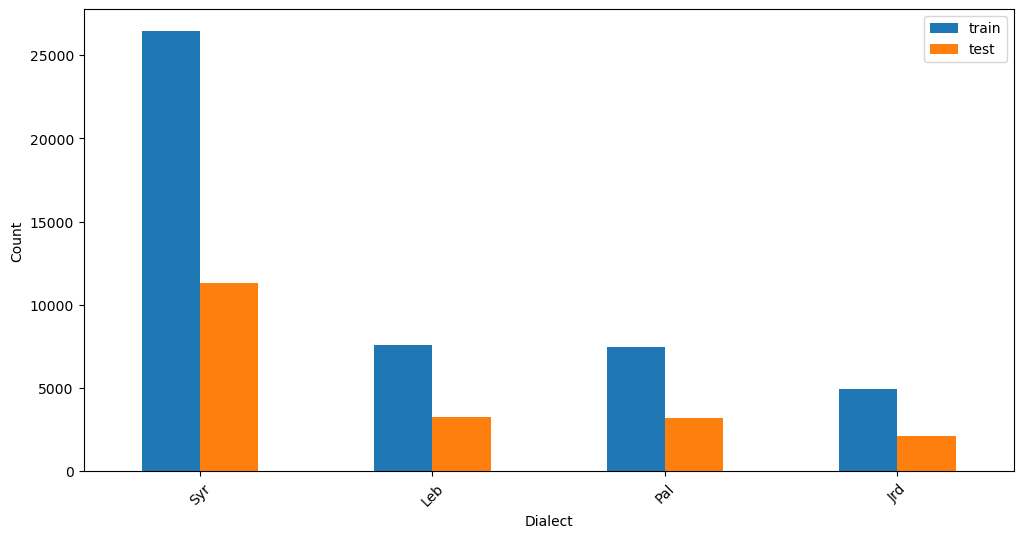

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Combine into a single DataFrame for comparison
distribution_df = pd.DataFrame({
    "train": train_counts,
    "test": test_counts
}).fillna(0).astype(int)  # fill missing dialects with 0

# Plot
distribution_df.plot(kind="bar", figsize=(12,6))
#plt.title("Dialect Distribution Across Train, Test, and Validation Sets")
plt.xlabel("Dialect")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

In [15]:
label_list = list(train[LABEL_COLUMN].unique())
print(label_list)

print("Training length: ", len(train))
print("Testing length: ", len(test))
# print("Validation length: ", len(val))


SHAMI_dataset = CustomDataset("SHAMI", train, test, label_list)
all_datasets.append(SHAMI_dataset)

['Leb', 'Pal', 'Syr', 'Jrd']
Training length:  46371
Testing length:  19876


In [16]:
!pip install tf-keras

In [17]:
import numpy as np
import torch
import random
import matplotlib.pyplot as plt
import copy
import os
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["USE_TF"] = "0"
from arabert.preprocess import ArabertPreprocessor
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score, precision_score,
                             recall_score)
from torch.utils.data import DataLoader, Dataset
from transformers import (AutoConfig, AutoModelForSequenceClassification,
                          AutoTokenizer, BertTokenizer, Trainer,
                          TrainingArguments)
from transformers.data.processors.utils import InputFeatures

In [18]:
dataset_name = 'SHAMI'
# select a model from the huggingface modelhub https://huggingface.co/models?language=ar
model_name = 'aubmindlab/bert-base-arabertv02-twitter' # we are going to use the twitter AraBERT since it has emojis and dialects
#model_name = "UBC-NLP/MARBERT"
# model_name = "CAMeL-Lab/bert-base-arabic-camelbert-mix"
#model_name = "xlm-roberta-base"
#model_name = "bert-base-multilingual-cased"
# model_name = "cis-lmu/glotlid"

In [19]:
for d in all_datasets:
  if d.name==dataset_name:
    selected_dataset = copy.deepcopy(d)
    print('Dataset found')
    break

Dataset found


In [20]:
arabic_prep = ArabertPreprocessor(model_name)

selected_dataset.train[DATA_COLUMN] = selected_dataset.train[DATA_COLUMN].apply(lambda x: arabic_prep.preprocess(x))
selected_dataset.test[DATA_COLUMN] = selected_dataset.test[DATA_COLUMN].apply(lambda x: arabic_prep.preprocess(x))

/home/pc2/Documents/work_to_do/SHAMI/arabert/preprocess.py:398: SyntaxWarning: invalid escape sequence '\`'
  text = re.sub(WHITE_SPACED_BACK_QUOTATION_REGEX, "\`" + r"\1" + "\`", text)
/home/pc2/Documents/work_to_do/SHAMI/arabert/preprocess.py:398: SyntaxWarning: invalid escape sequence '\`'
  text = re.sub(WHITE_SPACED_BACK_QUOTATION_REGEX, "\`" + r"\1" + "\`", text)
/home/pc2/Documents/work_to_do/SHAMI/arabert/preprocess.py:492: SyntaxWarning: invalid escape sequence '\d'
  "(\d+)([\u0621-\u063A\u0641-\u064A\u066A-\u066C\u0654-\u0655]+)",
/home/pc2/Documents/work_to_do/SHAMI/arabert/preprocess.py:497: SyntaxWarning: invalid escape sequence '\d'
  "([\u0621-\u063A\u0641-\u064A\u066A-\u066C\u0654-\u0655]+)(\d+)",
/home/pc2/Documents/work_to_do/SHAMI/arabert/preprocess.py:558: SyntaxWarning: invalid escape sequence '\['
  "([^0-9\u0621-\u063A\u0641-\u064A\u0660-\u0669a-zA-Z\[\]])",
/home/pc2/Documents/work_to_do/SHAMI/arabert/preprocess.py:565: SyntaxWarning: invalid escape sequence '\

AttributeError: module 'emoji' has no attribute 'UNICODE_EMOJI'

In [21]:
max_len = 300

In [22]:
class ClassificationDataset(Dataset):
    def __init__(self, text, target, model_name, max_len, label_map):
      super(ClassificationDataset).__init__()
      """
      Args:
      text (List[str]): List of the training text
      target (List[str]): List of the training labels
      tokenizer_name (str): The tokenizer name (same as model_name).
      max_len (int): Maximum sentence length
      label_map (Dict[str,int]): A dictionary that maps the class labels to integer
      """
      self.text = text
      self.target = target
      self.tokenizer_name = model_name
      self.tokenizer = AutoTokenizer.from_pretrained(model_name)
      self.max_len = max_len
      self.label_map = label_map


    def __len__(self):
      return len(self.text)

    def __getitem__(self,item):
      text = str(self.text[item])
      text = " ".join(text.split())

      inputs = self.tokenizer(
          text,
          max_length=self.max_len,
          padding='max_length',
          truncation=True
      )
      return InputFeatures(**inputs,label=self.label_map[self.target[item]])

In [23]:
label_map = { v:index for index, v in enumerate(selected_dataset.label_list) }
print(label_map)

{'Leb': 0, 'Pal': 1, 'Syr': 2, 'Jrd': 3}


In [24]:
def model_init():
    return AutoModelForSequenceClassification.from_pretrained(model_name, return_dict=True, num_labels=len(label_map))

In [25]:
def compute_metrics(p): #p should be of type EvalPrediction
  preds = np.argmax(p.predictions, axis=1)
  assert len(preds) == len(p.label_ids)
  #print(classification_report(p.label_ids,preds))
  #print(confusion_matrix(p.label_ids,preds))
  macro_f1 = f1_score(p.label_ids,preds,average='macro')
  #macro_precision = precision_score(p.label_ids,preds,average='macro')
  #macro_recall = recall_score(p.label_ids,preds,average='macro')
  acc = accuracy_score(p.label_ids,preds)
  return {
      'macro_f1' : macro_f1,
      'accuracy': acc
  }

In [26]:
def set_seed(seed=42):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic=True
  torch.backends.cudnn.benchmark = False

In [27]:
import transformers
print(transformers.__version__)

5.1.0


In [28]:
import os
os.environ["WANDB_MODE"] = "disabled"

In [29]:
from transformers import pipeline

In [30]:
# do kfold on the training. Check the perfomance on the test set
kfold_dataset = selected_dataset.train
# do kfold on all the dataset. Here we will not have any dataset to checl final performance on (this is used mainly in competitions)
# kfold_dataset = pd.concat([selected_dataset.train,selected_dataset.test])
kfold_dataset.reset_index(inplace=True,drop=True)

In [31]:
# this is used later
inv_label_map = { v:k for k, v in label_map.items()}

In [32]:
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=123
  )

In [33]:
all_results = []
fold_best_f1 = 0
best_fold = None
for fold_num , (train, dev) in enumerate(kf.split(kfold_dataset,kfold_dataset['label'])):
  print("**************************Starting Fold Num: ", fold_num," **************************")

  train_dataset = ClassificationDataset(list(kfold_dataset[DATA_COLUMN][train]),
                              list(kfold_dataset[LABEL_COLUMN][train]),
                              model_name,
                              max_len,
                              label_map)

  val_dataset = ClassificationDataset(list(kfold_dataset[DATA_COLUMN][dev]),
                              list(kfold_dataset[LABEL_COLUMN][dev]),
                              model_name,
                              max_len,
                              label_map)

  training_args = TrainingArguments(
    output_dir= f"./train_{fold_num}",
    adam_epsilon = 1e-8,
    learning_rate = 2e-5,
    fp16 = True,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size = 128,
    gradient_accumulation_steps = 4,
    num_train_epochs= 10,
    warmup_ratio = 0,
    do_eval = True,
    eval_strategy="epoch",
    save_strategy = 'epoch',
    load_best_model_at_end = True,
    metric_for_best_model = 'macro_f1',
    greater_is_better = True,
    seed = 123
  )

  set_seed(training_args.seed)
  model = model_init()
  model.gradient_checkpointing_enable()
  trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
  )
  trainer.model.config.label2id = label_map
  trainer.model.config.id2label = inv_label_map

  trainer.train()

  results = trainer.evaluate()
  all_results.append(results)
  print(results)

  trainer.save_model(f"./train_{fold_num}/best_model")
  val_dataset.tokenizer.save_pretrained(f"./train_{fold_num}/best_model")

  # delete the rest of the checkpoints
  !rm -rf f"./train_{fold_num}/checkpoint-*"

  if results['eval_macro_f1'] > fold_best_f1:
    print('**************************New Best Model Found!**************************')
    fold_best_f1 = results['eval_macro_f1']
    best_fold = fold_num

**************************Starting Fold Num:  0  **************************


config.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/476 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'eval_loss': 0.8492286205291748, 'eval_macro_f1': 0.8687661830434369, 'eval_accuracy': 0.9092085400043132, 'eval_runtime': 31.5555, 'eval_samples_per_second': 293.895, 'eval_steps_per_second': 2.313, 'epoch': 10.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [34]:
all_results

[{'eval_loss': 0.8395150899887085,
  'eval_macro_f1': 0.8655723737003936,
  'eval_accuracy': 0.9088948787061994,
  'eval_runtime': 31.5807,
  'eval_samples_per_second': 293.692,
  'eval_steps_per_second': 2.312,
  'epoch': 10.0},
 {'eval_loss': 0.7834055423736572,
  'eval_macro_f1': 0.8689626000634937,
  'eval_accuracy': 0.9083459133060168,
  'eval_runtime': 31.4985,
  'eval_samples_per_second': 294.426,
  'eval_steps_per_second': 2.318,
  'epoch': 10.0},
 {'eval_loss': 0.8026724457740784,
  'eval_macro_f1': 0.8607806403798428,
  'eval_accuracy': 0.905865861548415,
  'eval_runtime': 31.4915,
  'eval_samples_per_second': 294.492,
  'eval_steps_per_second': 2.318,
  'epoch': 10.0},
 {'eval_loss': 0.8044527173042297,
  'eval_macro_f1': 0.8658633310313146,
  'eval_accuracy': 0.908992883329739,
  'eval_runtime': 31.4936,
  'eval_samples_per_second': 294.472,
  'eval_steps_per_second': 2.318,
  'epoch': 10.0},
 {'eval_loss': 0.8492286205291748,
  'eval_macro_f1': 0.8687661830434369,
  'eval_

In [35]:
from statistics import mean
mean([x['eval_macro_f1'] for x in all_results])

0.8659890256436963

In [36]:
from transformers import pipeline
import more_itertools

In [37]:
inv_label_map = { v:k for k, v in label_map.items()}

In [38]:
pred_df = selected_dataset.test[DATA_COLUMN]

In [39]:
cross_val_df = pd.DataFrame([])
for i in range(0,5):
  pipe = pipeline("text-classification", model=f"train_{i}/best_model", device=0, return_all_scores =True, max_length=max_len, truncation=True)
  preds = []
  for s in tqdm(more_itertools.chunked(list(pred_df), 32)): # batching for faster inference
    preds.extend(pipe(s))
  cross_val_df[f'model_{i}'] = preds

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/tmp/ipykernel_121037/4020416005.py:5: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for s in tqdm(more_itertools.chunked(list(pred_df), 32)): # batching for faster inference


0it [00:00, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

/tmp/ipykernel_121037/4020416005.py:5: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for s in tqdm(more_itertools.chunked(list(pred_df), 32)): # batching for faster inference


0it [00:00, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

/tmp/ipykernel_121037/4020416005.py:5: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for s in tqdm(more_itertools.chunked(list(pred_df), 32)): # batching for faster inference


0it [00:00, ?it/s]

In [40]:
print(cross_val_df.head())

                                         model_0  \
0  {'label': 'Leb', 'score': 0.9978542923927307}   
1  {'label': 'Leb', 'score': 0.9999878406524658}   
2  {'label': 'Syr', 'score': 0.9999982118606567}   
3  {'label': 'Leb', 'score': 0.9999815225601196}   
4  {'label': 'Leb', 'score': 0.9999971389770508}   

                                         model_1  \
0  {'label': 'Jrd', 'score': 0.6940867900848389}   
1  {'label': 'Leb', 'score': 0.9999812841415405}   
2  {'label': 'Syr', 'score': 0.9999954700469971}   
3  {'label': 'Leb', 'score': 0.9999397993087769}   
4  {'label': 'Leb', 'score': 0.9999977350234985}   

                                         model_2  \
0  {'label': 'Leb', 'score': 0.9996281862258911}   
1  {'label': 'Leb', 'score': 0.9999809265136719}   
2  {'label': 'Syr', 'score': 0.9999908208847046}   
3  {'label': 'Leb', 'score': 0.9999697208404541}   
4  {'label': 'Leb', 'score': 0.9999947547912598}   

                                         model_3  \
0   {'lab

In [41]:
# from collections import defaultdict

# final_labels = []
# final_scores = []

# for _, row in cross_val_df.iterrows():
#     total_score = defaultdict(float)

#     for col in cross_val_df.columns:
#         for cls in row[col]:
#             total_score[cls['label']] += cls['score']

#     avg_score = {k: v / 5 for k, v in total_score.items()}

#     best_label = max(avg_score, key=avg_score.get)
#     final_labels.append(best_label)
#     final_scores.append(avg_score[best_label])


In [ ]:
# for _, row in cross_val_df.iterrows():
#     total_score = defaultdict(float)

#     for col in cross_val_df.columns:
#         for cls in row[col]:
#             total_score[cls['label']] += cls['score']
            

In [43]:
# len(final_scores)
avg_score

NameError: name 'avg_score' is not defined

In [44]:
from collections import defaultdict

model_cols = [c for c in cross_val_df.columns if c.startswith("model_")]

final_labels = []
final_scores = []

for _, row in cross_val_df.iterrows():
    total_score = defaultdict(float)

    for col in model_cols:
        pred = row[col]  # this IS a dict
        total_score[pred['label']] += pred['score']

    avg_score = {k: v / len(model_cols) for k, v in total_score.items()}
    best_label = max(avg_score, key=avg_score.get)

    final_labels.append(best_label)
    final_scores.append(avg_score[best_label])

In [45]:
model_cols

['model_0', 'model_1', 'model_2', 'model_3', 'model_4']

In [46]:
total_score.items()

dict_items([('Jrd', 4.999975681304932)])

In [47]:
cross_val_df['preds'] = final_labels
cross_val_df['DETECT_score'] = final_scores

In [48]:
cross_val_df['preds'].value_counts()

preds
Syr    11570
Pal     3271
Leb     3114
Jrd     1921
Name: count, dtype: int64

In [49]:
report = classification_report(selected_dataset.test[LABEL_COLUMN],cross_val_df['preds'])

In [50]:
print(report)

              precision    recall  f1-score   support

         Jrd       0.81      0.74      0.77      2106
         Leb       0.90      0.86      0.88      3249
         Pal       0.85      0.87      0.86      3193
         Syr       0.95      0.97      0.96     11328

    accuracy                           0.91     19876
   macro avg       0.88      0.86      0.87     19876
weighted avg       0.91      0.91      0.91     19876



In [51]:
with open(f"{dataset_name}_Arbert_classification_report.xlsx", "w") as ff:
    ff.write(report)

In [52]:
with open(f"{dataset_name}_Arbert_classification_report.txt", "w") as f:
    f.write(report)

In [53]:
with open(f"{dataset_name}_Arbert_classification_report.xls", "w") as ff:
    ff.write(report)